# Frangi Filter Baseline for Vascular Segmentation

アルゴリズムベースのベースライン。Green channel + CLAHE + Frangi filter で血管を検出し、
DL手法との比較基準とする。

色重み付け（彩度、R-G差分等）を検証した結果、Frangiの限界は **Dice ≈ 0.35**。
血管と背景の色分布が大きく重なるため色フィルタの効果は限定的。

**前提:** `prepare_data.ipynb` を実行済みで、`data/images/`, `data/masks/`, `data/circle_masks/` が存在すること。

In [15]:
import os
import cv2
import numpy as np
from pathlib import Path
from skimage.filters import frangi
import matplotlib.pyplot as plt

DATA_DIR = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project\vascular_segmentation\data')
IMG_DIR = DATA_DIR / 'images'
MASK_DIR = DATA_DIR / 'masks'
CIRCLE_DIR = DATA_DIR / 'circle_masks'

# レンズ縁erosion: Frangiがレンズ縁の強エッジを血管として誤検出するため、
# circle_maskを内側に縮小して縁を評価範囲から除外する
ERODE_PX = 10  # 512x512上で10px（元画像で約15px相当）

image_files = sorted(IMG_DIR.glob('*.png'))
print(f'Found {len(image_files)} images')
print(f'Circle mask erosion: {ERODE_PX}px')

Found 22 images
Circle mask erosion: 10px


## 1. Frangi Filter Pipeline

In [ ]:
def compute_metrics(pred: np.ndarray, gt: np.ndarray, mask: np.ndarray) -> dict:
    """circle_mask内でDice, IoU, Sensitivity, Specificity, Precisionを計算。"""
    valid = mask > 0
    p = pred[valid] > 0
    g = gt[valid] > 0
    
    tp = int(np.sum(p & g))
    fp = int(np.sum(p & ~g))
    fn = int(np.sum(~p & g))
    tn = int(np.sum(~p & ~g))
    
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    return {'dice': dice, 'iou': iou, 'sensitivity': sens, 'specificity': spec, 'precision': prec}


def frangi_green(img_bgr: np.ndarray, sigmas=range(1, 12)):
    """Green channel + CLAHE + Frangi filter."""
    green = img_bgr[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(green)
    inverted = 255 - enhanced
    resp = frangi(inverted.astype(np.float64) / 255.0, sigmas=sigmas, black_ridges=False)
    if resp.max() > 0:
        resp = resp / resp.max()
    return resp


def frangi_sat_rg(img_bgr: np.ndarray, sigmas=range(1, 12)):
    """Green Frangi × Saturation × (R-G): 色情報で血管をブースト。
    
    検証結果: Dice 0.325→0.346 (+0.021) の微小改善。
    血管と背景の色分布が重なるため、色フィルタの効果は限定的。
    """
    resp = frangi_green(img_bgr, sigmas)
    
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1].astype(np.float64) / 255.0
    
    r = img_bgr[:, :, 2].astype(np.float64)
    g = img_bgr[:, :, 1].astype(np.float64)
    rg = np.clip(r - g, 0, None)
    if rg.max() > 0:
        rg = rg / rg.max()
    
    weighted = resp * s * rg
    if weighted.max() > 0:
        weighted = weighted / weighted.max()
    return weighted


METHODS = {
    'A_green': frangi_green,
    'B_sat_rg': frangi_sat_rg,
}
print(f'Defined {len(METHODS)} Frangi methods: {list(METHODS.keys())}')

## 2. Compute All Methods + Threshold Optimization

全画像×全手法のFrangiレスポンスを計算し、手法ごとに最適閾値をグリッドサーチ

In [17]:
# Compute responses for all images × all methods
all_data = {}  # method_name -> list of {stem, resp, gt, circle}
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * ERODE_PX + 1, 2 * ERODE_PX + 1))

for method_name, method_fn in METHODS.items():
    all_data[method_name] = []
    print(f'\n--- {method_name} ---')
    for img_path in image_files:
        stem = img_path.stem
        img = cv2.imread(str(img_path))
        gt = cv2.imread(str(MASK_DIR / f'{stem}.png'), cv2.IMREAD_GRAYSCALE)
        circle = cv2.imread(str(CIRCLE_DIR / f'{stem}.png'), cv2.IMREAD_GRAYSCALE)
        circle_eroded = cv2.erode(circle, kernel, iterations=1)
        
        resp = method_fn(img)
        resp[circle_eroded == 0] = 0
        
        all_data[method_name].append({
            'stem': stem, 'resp': resp, 'gt': gt, 'circle': circle_eroded
        })
        print(f'  {stem[:8]}... done')

print(f'\nAll methods computed')


--- A_green ---
  0E900037... done
  1C329021... done
  204B89BA... done
  286D9676... done
  30A0F797... done
  366E2260... done
  56EF17CB... done
  5B763EC2... done
  6B193D74... done
  6F6D768A... done
  6FB55DC4... done
  7BA9B019... done
  7E4ADD96... done
  83FA07F4... done
  8C54C54A... done
  94D75FAA... done
  9AE4931C... done
  9CA1796B... done
  A1D04A1C... done
  B301995C... done
  B6257B84... done
  DD8633C6... done

--- B_color_weighted ---
  0E900037... done
  1C329021... done
  204B89BA... done
  286D9676... done
  30A0F797... done
  366E2260... done
  56EF17CB... done
  5B763EC2... done
  6B193D74... done
  6F6D768A... done
  6FB55DC4... done
  7BA9B019... done
  7E4ADD96... done
  83FA07F4... done
  8C54C54A... done
  94D75FAA... done
  9AE4931C... done
  9CA1796B... done
  A1D04A1C... done
  B301995C... done
  B6257B84... done
  DD8633C6... done

--- C_rg_diff ---
  0E900037... done
  1C329021... done
  204B89BA... done
  286D9676... done
  30A0F797... done
  366E2

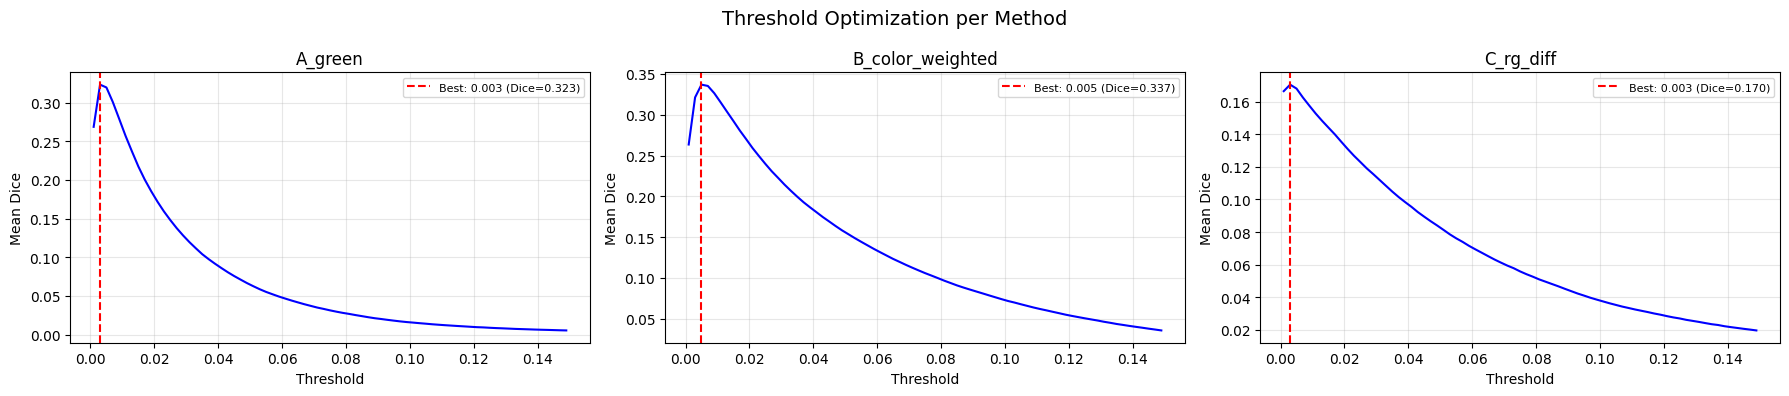


=== Best Results per Method ===
  A_green                  : Dice=0.323 (thr=0.003)
  B_color_weighted         : Dice=0.337 (thr=0.005)
  C_rg_diff                : Dice=0.170 (thr=0.003)


In [18]:
# Threshold optimization per method
thresholds = np.arange(0.001, 0.15, 0.002)
best_results = {}

fig, axes = plt.subplots(1, len(METHODS), figsize=(6 * len(METHODS), 4))
if len(METHODS) == 1:
    axes = [axes]

for ax, (method_name, data_list) in zip(axes, all_data.items()):
    mean_dices = []
    for thr in thresholds:
        dices = []
        for d in data_list:
            pred = (d['resp'] > thr).astype(np.uint8) * 255
            m = compute_metrics(pred, d['gt'], d['circle'])
            dices.append(m['dice'])
        mean_dices.append(np.mean(dices))
    
    best_idx = np.argmax(mean_dices)
    best_thr = thresholds[best_idx]
    best_dice = mean_dices[best_idx]
    best_results[method_name] = {'threshold': best_thr, 'dice': best_dice}
    
    ax.plot(thresholds, mean_dices, 'b-')
    ax.axvline(best_thr, color='r', linestyle='--', label=f'Best: {best_thr:.3f} (Dice={best_dice:.3f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Mean Dice')
    ax.set_title(f'{method_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Threshold Optimization per Method', fontsize=14)
plt.tight_layout()
plt.show()

print('\n=== Best Results per Method ===')
for name, res in best_results.items():
    print(f'  {name:25s}: Dice={res["dice"]:.3f} (thr={res["threshold"]:.3f})')

## 3. Per-Image Evaluation at Best Threshold

In [19]:
import pandas as pd

# Evaluate all methods at their best threshold
all_method_dfs = {}

for method_name, data_list in all_data.items():
    thr = best_results[method_name]['threshold']
    results = []
    for d in data_list:
        pred = (d['resp'] > thr).astype(np.uint8) * 255
        m = compute_metrics(pred, d['gt'], d['circle'])
        m['filename'] = d['stem']
        results.append(m)
    all_method_dfs[method_name] = pd.DataFrame(results)

# Summary comparison table
print('=== Method Comparison (Mean +/- Std) ===')
print(f'{"Method":25s} | {"Dice":>12s} | {"Precision":>12s} | {"Sensitivity":>12s}')
print('-' * 70)
for name, df in all_method_dfs.items():
    d = f'{df["dice"].mean():.3f}+/-{df["dice"].std():.3f}'
    p = f'{df["precision"].mean():.3f}+/-{df["precision"].std():.3f}'
    s = f'{df["sensitivity"].mean():.3f}+/-{df["sensitivity"].std():.3f}'
    print(f'{name:25s} | {d:>12s} | {p:>12s} | {s:>12s}')

# Select best method for detailed output and saving
best_method = max(best_results, key=lambda k: best_results[k]['dice'])
df_results = all_method_dfs[best_method]
best_threshold = best_results[best_method]['threshold']
print(f'\nBest method: {best_method} (Dice={best_results[best_method]["dice"]:.3f})')

# Prepare predictions for visualization (from best method)
frangi_data = all_data[best_method]  # reuse for visualization
predictions = []
for d in frangi_data:
    pred = (d['resp'] > best_threshold).astype(np.uint8) * 255
    predictions.append(pred)

=== Method Comparison (Mean +/- Std) ===
Method                    |         Dice |    Precision |  Sensitivity
----------------------------------------------------------------------
A_green                   | 0.323+/-0.165 | 0.268+/-0.145 | 0.433+/-0.209
B_color_weighted          | 0.337+/-0.200 | 0.314+/-0.193 | 0.398+/-0.240
C_rg_diff                 | 0.170+/-0.099 | 0.115+/-0.078 | 0.469+/-0.196

Best method: B_color_weighted (Dice=0.337)


## 4. Response Heatmap Comparison (sample images)

3手法のレスポンスをサンプル画像で比較し、ハレーション抑制効果を確認

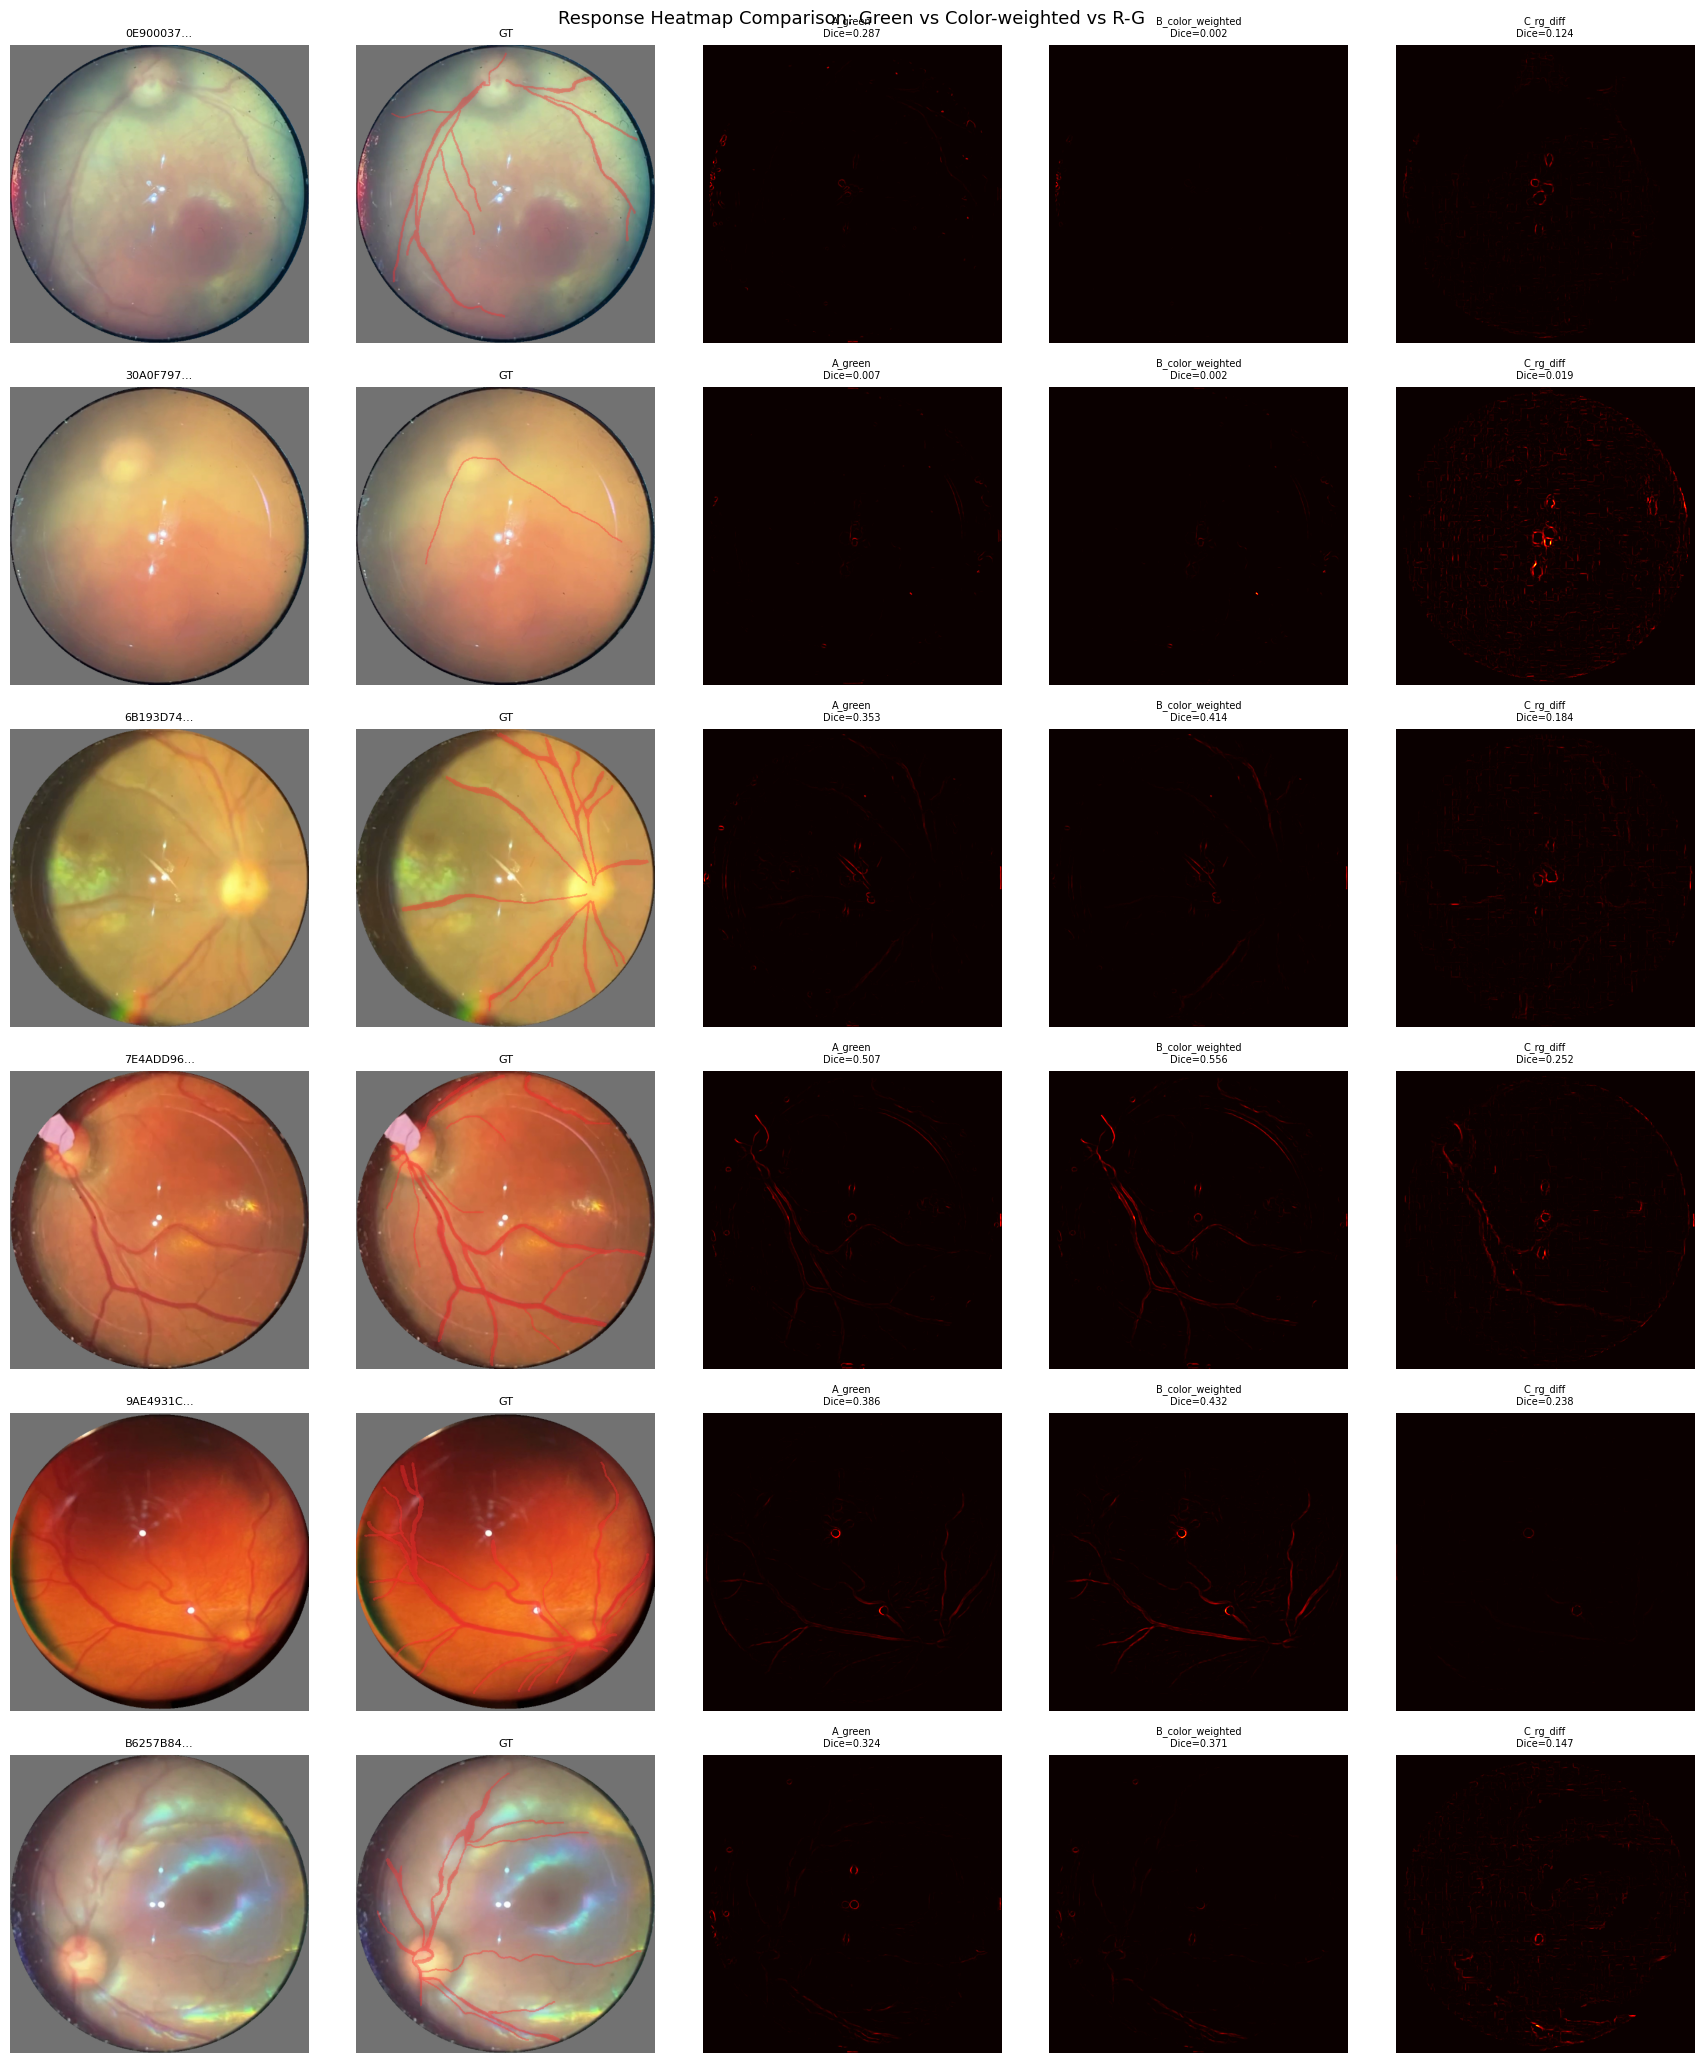

In [20]:
# Response heatmap comparison for sample images (every 4th image)
sample_indices = list(range(0, len(image_files), 4))[:6]
n_samples = len(sample_indices)
n_methods = len(METHODS)

fig, axes = plt.subplots(n_samples, n_methods + 2, figsize=(3.5 * (n_methods + 2), 3.5 * n_samples))

method_names = list(METHODS.keys())

for row, si in enumerate(sample_indices):
    stem = all_data[method_names[0]][si]['stem']
    gt = all_data[method_names[0]][si]['gt']
    
    # Col 0: Original image
    img = cv2.imread(str(IMG_DIR / f'{stem}.png'))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f'{stem[:8]}...', fontsize=8)
    axes[row, 0].axis('off')
    
    # Col 1: GT overlay
    overlay_gt = img_rgb.copy()
    overlay_gt[gt > 0] = [255, 50, 50]
    blended = cv2.addWeighted(img_rgb, 0.6, overlay_gt, 0.4, 0)
    axes[row, 1].imshow(blended)
    axes[row, 1].set_title('GT', fontsize=8)
    axes[row, 1].axis('off')
    
    # Cols 2+: Method heatmaps
    for col, mname in enumerate(method_names):
        resp = all_data[mname][si]['resp']
        axes[row, col + 2].imshow(resp, cmap='hot', vmin=0, vmax=1)
        thr = best_results[mname]['threshold']
        dice = all_method_dfs[mname].iloc[si]['dice']
        axes[row, col + 2].set_title(f'{mname}\nDice={dice:.3f}', fontsize=7)
        axes[row, col + 2].axis('off')

plt.suptitle('Response Heatmap Comparison: Green vs Color-weighted vs R-G', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# Save best method results for comparison with U-Net
df_results.to_csv(DATA_DIR.parent / 'frangi_results.csv', index=False)
print(f'Results saved ({best_method}): {DATA_DIR.parent / "frangi_results.csv"}')
print(f'\nFrangi Baseline Summary (best: {best_method}):')
print(f'  Mean Dice:      {df_results["dice"].mean():.3f}')
print(f'  Mean IoU:       {df_results["iou"].mean():.3f}')
print(f'  Mean Precision: {df_results["precision"].mean():.3f}')
print(f'  Mean Sensitivity: {df_results["sensitivity"].mean():.3f}')

Results saved (B_color_weighted): C:\Users\ykita\ROP_AI_project\ROP_project\vascular_segmentation\frangi_results.csv

Frangi Baseline Summary (best: B_color_weighted):
  Mean Dice:      0.337
  Mean IoU:       0.218
  Mean Precision: 0.314
  Mean Sensitivity: 0.398
